# FGSM Attack on MNIST-10

**Objective.** Craft adversarial examples for a 10-class MNIST digit classifier using the single-step Fast Gradient Sign Method (FGSM), then train a binary detector and test whether detection generalizes across attack strengths.

## What you will do

1. Load the MNIST dataset and train a small CNN classifier from scratch.
2. Configure and run the FGSM attack with the Adversarial Robustness Toolbox (ART) to generate adversarial examples.
3. Measure the damage: clean accuracy vs. adversarial accuracy, and the size of the perturbation.
4. Visualize clean vs. adversarial digits alongside the model's predictions.
5. Generate a balanced clean/adversarial dataset and train a binary detector, then sweep the attack strength to test whether detection generalizes.

## Prerequisites

- Comfortable with CNNs, the white-box threat model (the attacker knows the architecture, weights, and loss, and can compute the gradient of the loss with respect to the input), the L-infinity norm, and cross-entropy loss.

## Running this notebook

This is a self-contained notebook: it downloads MNIST, trains its own classifier, and generates its own adversarial examples, so no external model or dataset files are required. Run the cells top to bottom, on Colab or locally.

## Background: the FGSM attack

FGSM (Goodfellow, Shlens & Szegedy, 2015) is the simplest **max-loss** attack and the single-step special case of PGD. It takes exactly one step of size `eps` in the direction that increases the loss, using only the *sign* of the gradient so every pixel moves by the full budget:

$$x' = \text{clip}\big(x + \epsilon \cdot \text{sign}\big(\nabla_x L(x, y)\big),\; 0,\; 1\big).$$

- **Perturbation budget (epsilon).** The L-infinity cap on per-pixel change; here `eps = 0.2` on the `[0, 1]` scale, roughly 51 out of 255 raw intensity units.
- **One gradient computation.** That is what makes FGSM fast and a natural baseline, but a single step is a crude approximation of the constrained maximum, so FGSM is reliably weaker than the iterative PGD attack.

After building the attack, we cross from attacking to defending: we train a binary CNN detector to separate clean from adversarial inputs, then sweep epsilon to test whether a detector tuned at one strength generalizes to others. Detection is an empirical defense with no guarantee.

## 1. Setup

Install the Adversarial Robustness Toolbox (ART), then import the libraries. TensorFlow/Keras, NumPy, and Matplotlib are usually already available; ART is not, so we install it here.

In [1]:
# ART (Adversarial Robustness Toolbox) provides the FGSM attack and the BinaryInputDetector.
# TensorFlow/Keras, NumPy, and Matplotlib are usually pre-installed (e.g. on Colab);
# uncomment the second line if your environment is missing them.
!pip install adversarial-robustness-toolbox
# !pip install tensorflow numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

# ART components used in this notebook:
# - KerasClassifier wraps a Keras model in ART's estimator interface.
# - FastGradientMethod is the single-step FGSM evasion attack.
# - BinaryInputDetector wraps a binary CNN as an adversarial-input detector.
from art.estimators.classification import KerasClassifier
from art.attacks.evasion import FastGradientMethod
from art.defences.detector.evasion import BinaryInputDetector

## 2. Load and prepare the data

MNIST is 28x28 grayscale images of handwritten digits (0-9). We normalize pixels to `[0, 1]`, add a trailing channel axis for the CNN, and one-hot encode the labels. **Normalization matters for FGSM:** the budget `eps` and the classifier's `clip_values` are both on this `[0, 1]` scale, so the data range and the attack settings must agree.

We keep the first 500 test images for the attack and evaluation steps below.

In [3]:
# Load MNIST and normalize pixel values from [0, 255] to [0, 1].
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel axis: (N, 28, 28) -> (N, 28, 28, 1).
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels for the 10 digit classes.
nb_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes=nb_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=nb_classes)

# Work with the first 500 test samples to keep the attack/evaluation steps fast.
x_test = x_test[:500]
y_test = y_test[:500]

print("x_train:", x_train.shape, "x_test:", x_test.shape, "pixel range:", (float(x_test.min()), float(x_test.max())))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28, 1) x_test: (500, 28, 28, 1) pixel range: (0.0, 1.0)


### A quick look at the clean data

Before training or attacking anything, sanity-check the inputs: one clean example per digit class, shown in grayscale. If these look wrong, every downstream figure will be unreliable.

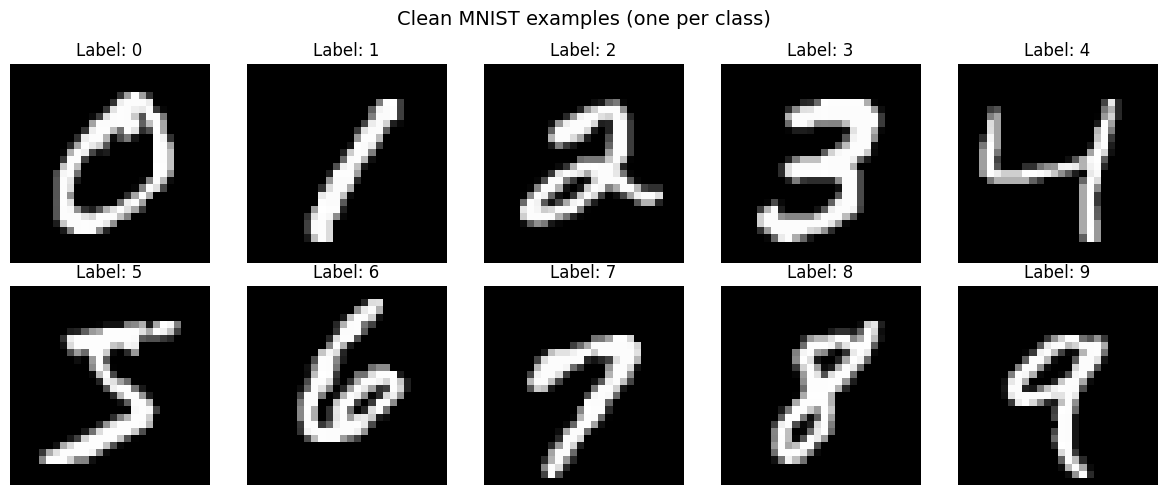

In [4]:
# Show one clean example per digit (0-9) in grayscale.
train_labels = np.argmax(y_train, axis=1)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(train_labels == i)[0][0]
    ax.imshow(x_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {i}", fontsize=12)
    ax.axis('off')
fig.suptitle("Clean MNIST examples (one per class)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Build and train the target model

The target is a small CNN: three convolution+pooling blocks feeding into two dense layers (a 128-unit hidden layer and a 10-way softmax output). We train it from scratch on clean MNIST with no adversarial defenses, so any accuracy drop under attack can be attributed to the attack rather than to weak or defended training.

We reuse this same architecture later for the clean-vs-adversarial detector, just with a 2-class output instead of 10.

In [5]:
def build_cnn_classifier(num_classes):
    """3 conv blocks + 2 dense layers. Used for both the target classifier
    (num_classes=10) and the clean-vs-adversarial detector (num_classes=2)."""
    return tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])


In [6]:
model = build_cnn_classifier(nb_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the target classifier on clean MNIST. A handful of epochs is enough
# for this architecture to reach roughly 99% clean test accuracy.
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 113ms/step - accuracy: 0.8817 - loss: 0.3768 - val_accuracy: 0.9688 - val_loss: 0.1091
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 107ms/step - accuracy: 0.9657 - loss: 0.1117 - val_accuracy: 0.9815 - val_loss: 0.0617
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - accuracy: 0.9766 - loss: 0.0762 - val_accuracy: 0.9845 - val_loss: 0.0511
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.9812 - loss: 0.0604 - val_accuracy: 0.9857 - val_loss: 0.0480
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9847 - loss: 0.0501 - val_accuracy: 0.9880 - val_loss: 0.0420


## 4. Configure and run the FGSM attack

### Wrap the model for ART

ART attacks operate on an *estimator*, not a raw Keras model. We wrap the classifier with `KerasClassifier` and declare the valid pixel range via `clip_values=(0.0, 1.0)`, which ART uses to clip adversarial examples back into a valid image range.

In [8]:
# Wrap the target model in ART's estimator interface.
# clip_values must match the normalized pixel range [0.0, 1.0].
classifier = KerasClassifier(model=model, clip_values=(0.0, 1.0), use_logits=False)

### Build the attack

FGSM has a single knob: the budget `eps`. We use `eps = 0.2` on the `[0, 1]` scale (about 51/255), a moderate, still barely-visible strength. You can change it later with `attack_fgsm.set_params(eps=...)`, which is what the strength sweep does.

In [9]:
# eps defines the perturbation budget. The smaller eps is, the smaller the attack's effect.
attack_fgsm = FastGradientMethod(estimator=classifier, eps=0.2)

### Generate adversarial examples

We run FGSM on the 500 held-out test images to produce `x_test_adv`. Since FGSM is a single gradient step per image, this is fast even at this eps.

In [10]:
# Generate FGSM adversarial examples for the 500 test images (eps = 0.2).
x_test_adv = attack_fgsm.generate(x=x_test)

print("x_test_adv:", x_test_adv.shape, "y_test:", y_test.shape)

x_test_adv: (500, 28, 28, 1) y_test: (500, 10)


## 5. Evaluate the attack

Clean accuracy (near 99%) vs. adversarial accuracy tells us the fooling rate, and the mean absolute per-pixel change tells us how small the perturbation was. A single-step attack that meaningfully drops accuracy with a small average change is the whole point of FGSM.

In [11]:
# Clean accuracy on the 500 clean test images.
_, clean_acc = model.evaluate(x_test, y_test, verbose=0)

# Adversarial accuracy on the FGSM examples.
_, adv_acc = model.evaluate(x_test_adv, y_test, verbose=0)

# Perturbation size between clean and adversarial images.
mean_abs = np.mean(np.abs(x_test_adv - x_test))
linf = np.max(np.abs(x_test_adv - x_test))

print(f"Clean accuracy:        {clean_acc * 100:5.2f}%")
print(f"Adversarial accuracy:  {adv_acc * 100:5.2f}%")
print(f"Fooling rate:          {(clean_acc - adv_acc) * 100:5.2f} percentage points")
print(f"Mean |perturbation|:   {mean_abs:.4f}  (per pixel, on the [0, 1] scale)")
print(f"L-infinity norm:       {linf:.4f}  (should be <= eps = 0.2)")

Clean accuracy:        98.20%
Adversarial accuracy:  53.40%
Fooling rate:          44.80 percentage points
Mean |perturbation|:   0.0695  (per pixel, on the [0, 1] scale)
L-infinity norm:       0.2000  (should be <= eps = 0.2)


## 6. Visualize clean vs. adversarial examples

The top row shows clean digits with the model's prediction; the bottom row shows the FGSM version of the same digit with the model's (now often wrong) prediction. The images look unchanged to us, yet the predictions flip. Green titles mark correct predictions, red marks the misclassifications the attack caused.

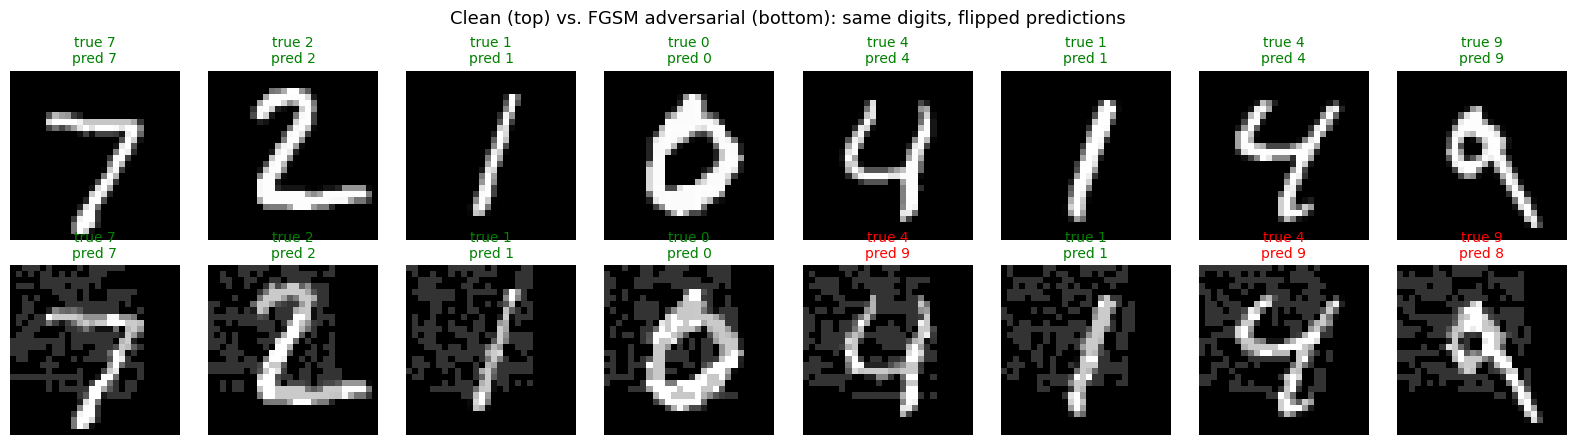

In [12]:
# Compare clean and adversarial versions of the same images side by side.
n = 8
clean_preds = np.argmax(model.predict(x_test[:n], verbose=0), axis=1)
adv_preds = np.argmax(model.predict(x_test_adv[:n], verbose=0), axis=1)
true_labels = np.argmax(y_test[:n], axis=1)

fig, axes = plt.subplots(2, n, figsize=(2 * n, 4.5))
for j in range(n):
    # Top row: clean image.
    axes[0, j].imshow(x_test[j].squeeze(), cmap='gray')
    color = 'green' if clean_preds[j] == true_labels[j] else 'red'
    axes[0, j].set_title(f"true {true_labels[j]}\npred {clean_preds[j]}", fontsize=10, color=color)
    axes[0, j].axis('off')

    # Bottom row: adversarial image.
    axes[1, j].imshow(x_test_adv[j].squeeze(), cmap='gray')
    color = 'green' if adv_preds[j] == true_labels[j] else 'red'
    axes[1, j].set_title(f"true {true_labels[j]}\npred {adv_preds[j]}", fontsize=10, color=color)
    axes[1, j].axis('off')

fig.suptitle("Clean (top) vs. FGSM adversarial (bottom): same digits, flipped predictions", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Adversarial-example detector

We now build a defense: a binary CNN that classifies each input as **clean** or **adversarial**, trained on a balanced 50/50 mix of clean images and their FGSM counterparts. FGSM's uniform sign-of-gradient perturbation leaves a systematic signature that a CNN can learn to spot.

### Generate the detector training data

We take 500 clean training images (disjoint from the test set used above) and attack them with the same FGSM attack at `eps = 0.2` to get 500 adversarial counterparts. Stacking the two gives a balanced set of 1000 samples with binary labels: `[1, 0]` = clean, `[0, 1]` = adversarial.

In [13]:
# 500 clean training images and their FGSM-adversarial counterparts (eps = 0.2).
x_train_clean_detector = x_train[:500]
x_train_adv_detector = attack_fgsm.generate(x=x_train_clean_detector)

x_train_detector = np.concatenate([x_train_clean_detector, x_train_adv_detector], axis=0)
y_train_detector = np.concatenate([
    np.tile([1, 0], (500, 1)),   # clean
    np.tile([0, 1], (500, 1)),   # adversarial
], axis=0).astype("float32")

# Shuffle so clean/adversarial examples are interleaved during training.
shuffle_idx = np.random.permutation(len(x_train_detector))
x_train_detector = x_train_detector[shuffle_idx]
y_train_detector = y_train_detector[shuffle_idx]

print("x_train_detector:", x_train_detector.shape, "y_train_detector:", y_train_detector.shape)

x_train_detector: (1000, 28, 28, 1) y_train_detector: (1000, 2)


### Build and train the detector

The detector reuses the same `build_cnn_classifier` architecture as the target model (3 conv blocks + 2 dense layers), just with a 2-class softmax head (clean vs. adversarial) instead of 10. A few epochs are enough because FGSM's structured perturbation makes the two classes well separated.

In [14]:
# Binary CNN detector: same architecture as the classifier, with a 2-class output head.
detector_model = build_cnn_classifier(2)
detector_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

detector_model.fit(x_train_detector, y_train_detector, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8220 - loss: 0.4320
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9980 - loss: 0.0163
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 3.2090e-04
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 2.0293e-04
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 7.8420e-05
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 6.6675e-05
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 1.0000 - loss: 1.0254e-04
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 1.0000 - loss: 1.0694e-04
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 6.7207e-05


### Wrap the detector with ART's BinaryInputDetector

`BinaryInputDetector` gives the detector the same ART interface as the attack, so `detect(x)` returns a per-sample adversarial flag. We wrap the trained Keras model with `KerasClassifier` (again with `clip_values=(0.0, 1.0)`) and hand it to the detector.

In [15]:
# Wrap the trained detector as an ART estimator, then in a BinaryInputDetector.
detector_classifier = KerasClassifier(model=detector_model, clip_values=(0.0, 1.0), use_logits=False)
detector = BinaryInputDetector(detector_classifier)

# Fit the detector within ART's interface on the balanced training set.
detector.fit(x_train_detector, y_train_detector, nb_epochs=3, batch_size=32)

### How well does the detector catch the eps = 0.2 attack?

We check both sides of the trade-off: how many of the 500 test-set adversarial images it flags (true positives), and how many of the 500 clean test images it wrongly flags (false positives). At the strength it was trained on, an FGSM detector usually catches almost every adversarial example while rarely tripping on clean data.

In [16]:
# Flagged adversarial examples (true positives).
_, flags_adv = detector.detect(x_test_adv)
n_flag_adv = int(np.sum(flags_adv))

# Flagged clean examples (false positives).
_, flags_clean = detector.detect(x_test)
n_flag_clean = int(np.sum(flags_clean))

print(f"Adversarial images flagged: {n_flag_adv} / {len(x_test_adv)}  (higher is better)")
print(f"Clean images flagged:       {n_flag_clean} / {len(x_test)}  (lower is better)")

Adversarial images flagged: 500 / 500  (higher is better)
Clean images flagged:       1 / 500  (lower is better)


### Does the detector generalize across attack strengths?

The detector was trained only on `eps = 0.2` examples. Now we sweep epsilon from very weak to very strong, regenerating FGSM examples at each strength, and count two things per 100 images:

- how many the **detector flags** as adversarial, and
- how many actually **fool the classifier**.

If detection were a general defense, the flagged curve would track the fooled curve everywhere. Watch what happens instead at strengths far from `0.2`.

In [17]:
# Sweep the perturbation budget. The detector was trained at eps = 0.2 only.
eps_range = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
n_samples = 100
x_probe = x_test[:n_samples]
y_probe = np.argmax(y_test[:n_samples], axis=1)

n_flagged = []   # detector flags per 100 samples
n_fooled = []    # classifier errors per 100 samples

for eps in eps_range:
    attack_fgsm.set_params(eps=eps)
    x_adv = attack_fgsm.generate(x=x_probe)
    n_flagged.append(int(np.sum(detector.detect(x_adv)[1])))
    preds = np.argmax(classifier.predict(x_adv), axis=1)
    n_fooled.append(int(np.sum(preds != y_probe)))

# Prepend the clean (eps = 0) baseline for reference.
clean_preds = np.argmax(classifier.predict(x_probe), axis=1)
eps_axis = [0.0] + eps_range
n_flagged = [n_flag_clean] + n_flagged
n_fooled = [int(np.sum(clean_preds != y_probe))] + n_fooled

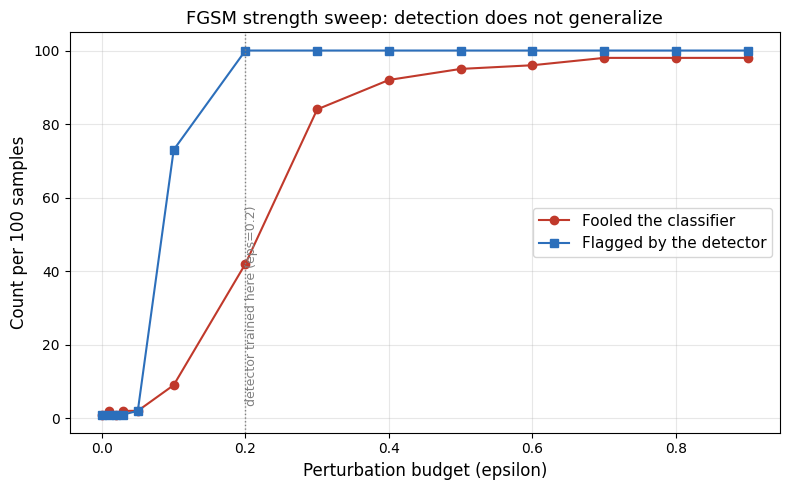

In [18]:
# Plot detector flags against classifier fooling as attack strength varies.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(eps_axis, n_fooled, marker='o', color='#c0392b', label='Fooled the classifier')
ax.plot(eps_axis, n_flagged, marker='s', color='#2c6fbb', label='Flagged by the detector')

# Mark the single strength the detector was trained on.
ax.axvline(0.2, color='gray', linestyle=':', linewidth=1)
ax.text(0.2, ax.get_ylim()[1] * 0.02, ' detector trained here (eps=0.2)',
        rotation=90, va='bottom', ha='left', fontsize=9, color='gray')

ax.set_xlabel('Perturbation budget (epsilon)', fontsize=12)
ax.set_ylabel(f'Count per {n_samples} samples', fontsize=12)
ax.set_title('FGSM strength sweep: detection does not generalize', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

> **Takeaway.** The detector is reliable only near the strength it was trained on (`eps = 0.2`). Turn the attack down and adversarial examples can still slip past while barely denting accuracy; turn it up and the flagged and fooled curves diverge. A detector calibrated at one epsilon does **not** generalize across the strength spectrum. Detection is an *empirical* defense: it works against the attacks you trained it on and offers no guarantee against the ones you did not.

## Key takeaways

- **FGSM is the fast baseline.** A single gradient step meaningfully drops a ~99% MNIST classifier's accuracy with a perturbation that is invisible to the eye, at a fraction of PGD's cost.
- **Single-step means weaker.** Compared with an iterative attack like PGD at the same budget, FGSM leaves more images correctly classified; it is a crude approximation of the constrained max-loss perturbation.
- **The budget epsilon controls the trade-off.** Larger `eps` gives a stronger, more visible attack; the L-infinity norm of every adversarial example stays within `eps`.
- **Detection is empirical, not guaranteed.** A detector trained at one epsilon catches that strength well but does not generalize across the spectrum. Stronger defenses exist beyond detection, such as adversarial training and certified methods like randomized smoothing, but they are outside the scope of this notebook.

## Comprehension Questions

1. The target classifier ends in a 10-unit softmax layer, but the detector built in Section 7 ends in a 2-unit softmax layer, even though both use `build_cnn_classifier`. Why does the detector only need 2 outputs, and what would change about its labels and loss if you wanted it to also report *which* attack produced an adversarial example (e.g. FGSM vs. PGD vs. none)?
2. FGSM takes exactly one gradient step, while PGD (the other attack in this course) takes many, each one projected back into the epsilon-ball. Based on the fooling rate you measured in Section 5, why does that extra iteration and projection make PGD a stronger attack than FGSM at the same `eps`?
3. **(General knowledge, non-technical.)** If you were shipping an image classifier in a public-facing product and later learned it was vulnerable to adversarial examples, would you disclose that before a defense was ready? What are the trade-offs of disclosing early versus staying quiet until a fix exists?

## Hands-On Tasks

Make each change directly in the relevant cell above, re-run the notebook from that point forward, and record what you observe (a sentence or two per task is enough).

1. **Change the model's capacity.** In `build_cnn_classifier`, either add one more convolutional block (`Conv2D` + `MaxPooling2D`) or remove one of the three existing blocks — pick one direction, not both. Retrain the target classifier from scratch and re-run the attack and evaluation cells at the same `eps = 0.2` you used originally. Report: did clean accuracy rise or fall compared to the original 3-block model? Did adversarial accuracy (the model's accuracy on `x_test_adv`) rise or fall? Based on that comparison, is the modified model more or less robust toward the same attack at the same perturbation budget (`eps`)?
2. **Grow the detector's training set.** In the "Generate the detector training data" cell, increase the balanced set from 500 clean + 500 adversarial images to **1000 clean + 1000 adversarial images (2000 samples total)**, then retrain the detector. Does the larger training set change how many clean images get falsely flagged, or how many adversarial images get caught?
3. **Weaken the attack.** Set `eps = 0.05` when you build `attack_fgsm` (instead of `0.2`), then re-run the attack-generation, evaluation, and visualization cells. Report the new clean vs. adversarial accuracy, the mean perturbation, and whether the detector (still trained at `eps = 0.2`) catches most of these weaker adversarial examples.

## Completion Criteria

You have completed this lab when:

- You added or removed a convolutional block, retrained the model, and can state whether clean accuracy and adversarial accuracy at `eps = 0.2` rose or fell, and whether the model became more or less robust as a result.
- You retrained the detector on a 1000 clean + 1000 adversarial set and can state whether detection performance changed relative to the 500/500 baseline.
- You re-ran the attack at `eps = 0.05` and reported the resulting clean/adversarial accuracy and perturbation size.
- You can explain why the detector has 2 outputs while the target classifier has 10.